# Exact Inference in Bayesian Networks

- This notebook teaches how to compute exact posteriors $P(X \mid \mathbf{e})$
  in a discrete Bayesian network
- Concepts are built on the the burglary-alarm network and the query
  $P(Burglary \mid JohnCalls, MaryCalls)$
- The flow is:
  - Inference by enumeration (brute force)
  - Variable elimination (caching)
  - Irrelevant-variable pruning
  - Complexity and limits

## Imports

In [13]:
%load_ext autoreload
%autoreload 2

# System libraries.
import logging

# Third-party libraries.

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [1]:
# Use this for most notebooks.
import helpers.hintrospection as hintros
import helpers.htutorial as htutori

import L06_01_exact_inference_utils as utils

htutori.config_notebook()

# Initialize logger.
_LOG = logging.getLogger(__name__)
utils.init_loggers(_LOG)

# Convert `display` into `print()` when running outside IPython.
try:
    from IPython.display import display
except ImportError:
    display = print  # type: ignore

/opt/venv/lib/python3.12/site-packages/pgmpy/estimators/__init__.py:4: FutureWarning: `pgmpy.estimators.StructureScore` is deprecated and will be removed in v1.3.0. Use `pgmpy.structure_score` instead.
  from .StructureScore import (
pymc is not installed
arviz is not installed
preliz is not installed
sns is not installed


Python 3.12.13
Linux 7f4d4ef8cf8c 6.12.67-linuxkit #1 SMP Sun Jan 25 02:26:28 UTC 2026 aarch64 GNU/Linux


NameError: name 'logging' is not defined

# Part 1: Setting Up the Inference Problem

## Cell 1.1: The burglary alarm network and its CPTs

**Goal**:
- Ground every later inference step in one concrete network: the
  burglary-alarm story and its five conditional probability tables
- The five variables are:
  - Root causes: $Burglary$, $Earthquake$ (blue)
  - The $Alarm$ (orange)
  - The calls: $JohnCalls$, $MaryCalls$ (purple)
- The joint factorizes into five small CPTs:
  $$P(B,E,A,J,M) = P(B)\,P(E)\,P(A \mid B,E)\,P(J \mid A)\,P(M \mid A)$$

**Implementation**: `cell1_1_show_network_and_cpts()`
- Draws the DAG colored by role, prints the priors $P(B)$/$P(E)$, the
  $P(Alarm \mid B, E)$ table, and the two call CPTs

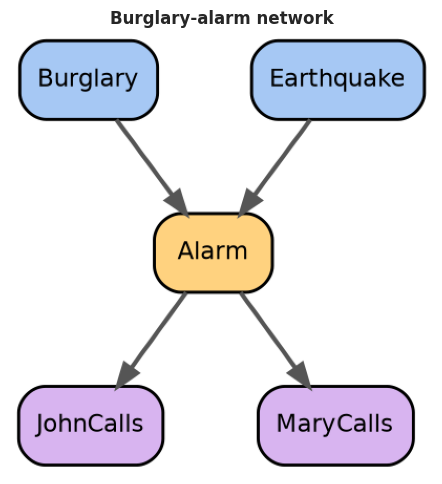

Priors on the root causes:


,Variable,P(True),P(False)
0,Burglary,0.001,0.999
1,Earthquake,0.002,0.998


P(Alarm | Burglary, Earthquake):


,Burglary,Earthquake,P(Alarm=T),P(Alarm=F)
0,F,F,0.001,0.999
1,F,T,0.290,0.710
2,T,F,0.940,0.060
3,T,T,0.950,0.050


P(JohnCalls | Alarm) and P(MaryCalls | Alarm):


,Alarm,P(JohnCalls=T),P(MaryCalls=T)
0,T,0.90,0.70
1,F,0.05,0.01


In [3]:
# Display the DAG and its five conditional probability tables.
utils.cell1_1_show_network_and_cpts()

# TODO(ai_gp): The prob for P(Alarm | Burglary, Earthquake) do not match
# the slides in L06.1
# TODO(ai_gp): The colors of the nodes are different than the slides

- The joint over five variables factorizes into five small CPTs
- Calls depend on the world only through $Alarm$: they are conditionally
  independent of $Burglary$ and $Earthquake$ given $Alarm$
- Storing 5 small CPTs (10 independent numbers) is far cheaper than the full
  joint ($2^5 - 1 = 31$ numbers)
- Inference never touches the full joint directly: it works with the factored
  form, a product of the small CPTs attached to each node

## Cell 1.2: Query, evidence, and hidden variables

**Goal**:
- Build intuition for which variables must be summed out, by letting
  students pick the query and mark any subset of nodes as evidence

**Implementation**: `cell1_2_query_roles_widget()`
- Recolors the DAG by role, query/evidence/hidden, for the current
  choice of `Query X` and observed nodes, via `_read_query()`
- Restates the query in math and counts the $2^{|\mathbf{Y}|}$ hidden
  terms in the Comments panel

In [ ]:
hintros.print_obj_info(utils.cell1_2_query_roles_widget)

**Usage**
- Inputs
  - **`Query X`**: which node is being asked about
  - **`observe <node>`**: one checkbox plus True/False value per node,
    marking it as evidence

- Panels
  - **`Roles for the current query`**: the DAG recolored by role: query
    (blue), evidence (red), hidden (grey)
  - **`Comments`**: the query restated in math, and the hidden-term
    count

In [4]:
# Assign each node a role and recolor the DAG for the current query.
utils.cell1_2_query_roles_widget()

**Guided usage**
- Mark every node except `Query X` as evidence
  - Observe no node stays hidden, and the term count in Comments drops
    to $2^0 = 1$: nothing needs to be summed out
- Uncheck every evidence box, leaving only `Query X` set
  - Observe every other node turns hidden, and the term count climbs to
    $2^4$: the posterior we want, $P(X \mid \mathbf{e})$, still has to
    marginalize all of them away, they cannot simply be dropped

# Part 2: Inference by Enumeration

## Cell 2.1: From conditional to joint via normalization

**Goal**:
- Derive why a conditional query reduces to summing the joint and
  rescaling by a normalization constant $\alpha$

**Implementation**: `cell2_1_normalization_widget()`
- Fixes the canonical query $P(Burglary \mid JohnCalls, MaryCalls)$ and
  computes both the unnormalized joint and the normalized posterior with
  `_enumerate_posterior()`
- `show normalization` switches the middle panel between the two views

In [ ]:
hintros.print_obj_info(utils.cell2_1_normalization_widget)

**Usage**
- Inputs
  - **`show normalization`**: toggle between the unnormalized joint
    $P(B, j, m)$ and the normalized posterior $P(B \mid j, m)$

- Panels
  - **`Derivation`**: the three equation lines from $P(X \mid e)$ down
    to the alarm-network sum
  - **`Unnormalized joint`/`Normalized posterior`**: bars for $B$=T/F in
    whichever view is toggled on
  - **`Comments`**: the unnormalized values, $\alpha$, and the
    resulting posterior

In [5]:
# Toggle between the unnormalized joint and the normalized posterior.
utils.cell2_1_normalization_widget()

**Guided usage**
- Toggle `show normalization` off, then on
  - Observe the bars change scale (they no longer sum to 1) but keep
    the same relative height: rescaling by $\alpha$ never changes which
    value is more likely, only the units
- Read $\alpha$ off the Comments panel
  - Observe $\alpha = 1 / \sum_x P(x, e)$: exactly the constant that
    makes the posterior sum to 1, computed without ever touching
    $P(e)$ directly

## Cell 2.2: Computing the posterior by enumeration

**Goal**:
- Compute the exact posterior by hand, summing CPT products over the
  hidden variables, and confirm it against the `pgmpy` engine

**Implementation**: `cell2_2_enumeration_widget()`
- Enumerates every hidden assignment and its CPT product with
  `_enumerate_posterior()`, for the current `Query X`/evidence
- Cross-checks the result against `pgmpy`'s `VariableElimination`
  reference

In [ ]:
hintros.print_obj_info(utils.cell2_2_enumeration_widget)

**Usage**
- Inputs
  - **`Query X`**: which node is being asked about
  - **`observe <node>`**: one checkbox plus True/False value per node,
    marking it as evidence

- Panels
  - **`Sum for X=T`/`Sum for X=F`**: every hidden assignment and its
    CPT product, for each query value
  - **`Posterior`**: the resulting bars, with the `pgmpy` reference
    overlaid in dashed red
  - **`Comments`**: hidden-variable count, row count summed, and
    whether the two engines agree

In [6]:
# Compute the posterior by enumeration and validate against pgmpy.
utils.cell2_2_enumeration_widget()

**Guided usage**
- Mark one more node as evidence, then another
  - Observe the row count in Comments halve each time: one fewer
    hidden variable means one fewer factor of 2 in $2^{|\mathbf{Y}|}$
- Compare the enumeration bars against the dashed `pgmpy` reference for
  several different queries
  - Observe they always coincide: hand enumeration and the library
    engine compute the same posterior, e.g. the famous result
    $P(Burglary \mid j,m) \approx 0.284$

## Cell 2.3: Visualizing the enumeration tree

**Goal**:
- Expose the enumeration computation as a tree, to see the repeated
  subexpressions that motivate variable elimination

**Implementation**: `cell2_3_enumeration_tree_widget()`
- Draws the two-level branch tree over the hidden `Earthquake`/`Alarm`
  values, for the fixed query $P(Burglary \mid j, m)$
- Colors each leaf's shared $P(j \mid a)P(m \mid a)$ factor by the value
  of `Alarm` on that branch, when highlighting is on

In [ ]:
hintros.print_obj_info(utils.cell2_3_enumeration_tree_widget)

**Usage**
- Inputs
  - **`Sum order`**: which hidden variable branches first, `Earthquake`
    or `Alarm`
  - **`highlight repeated work`**: color leaves by their shared factor

- Panels
  - **`Enumeration evaluation tree`**: the branch tree, leaves labeled
    by their CPT product
  - **`Comments`**: the operation count and why the repeats are wasteful

In [7]:
# Draw the enumeration tree and highlight the repeated subexpressions.
utils.cell2_3_enumeration_tree_widget()

**Guided usage**
- Turn on `highlight repeated work`
  - Observe leaves under different first-level branches share the same
    color whenever `Alarm` agrees: the identical $P(j \mid a)P(m \mid a)$
    factor is recomputed in more than one branch
- Switch `Sum order` between the two options
  - Observe the tree's shape changes, but the same repeated-factor
    pattern persists either way: caching it once, instead of
    recomputing it per branch, is the one idea behind variable
    elimination

# Part 3: Variable Elimination

## Cell 3.1: Factors as the unit of computation

**Goal**:
- Introduce the factor, a table over a subset of variables, as the
  single data structure variable elimination manipulates

**Implementation**: `cell3_1_factor_operations_widget()`
- Renders the chosen CPT as a `Factor` table, then marginalizes out
  `Sum out` with `pgmpy`'s `factor.marginalize()`

In [ ]:
hintros.print_obj_info(utils.cell3_1_factor_operations_widget)

**Usage**
- Inputs
  - **`Factor`**: which CPT to view as a factor, labeled by its scope
  - **`Sum out`**: which variable in that factor's scope to marginalize
    away

- Panels
  - **`Before`**: the selected factor's table and scope
  - **`After summing out <var>`**: the same factor once that variable
    is marginalized out
  - **`Comments`**: how many rows the table shrank by, and the two
    operations inference needs

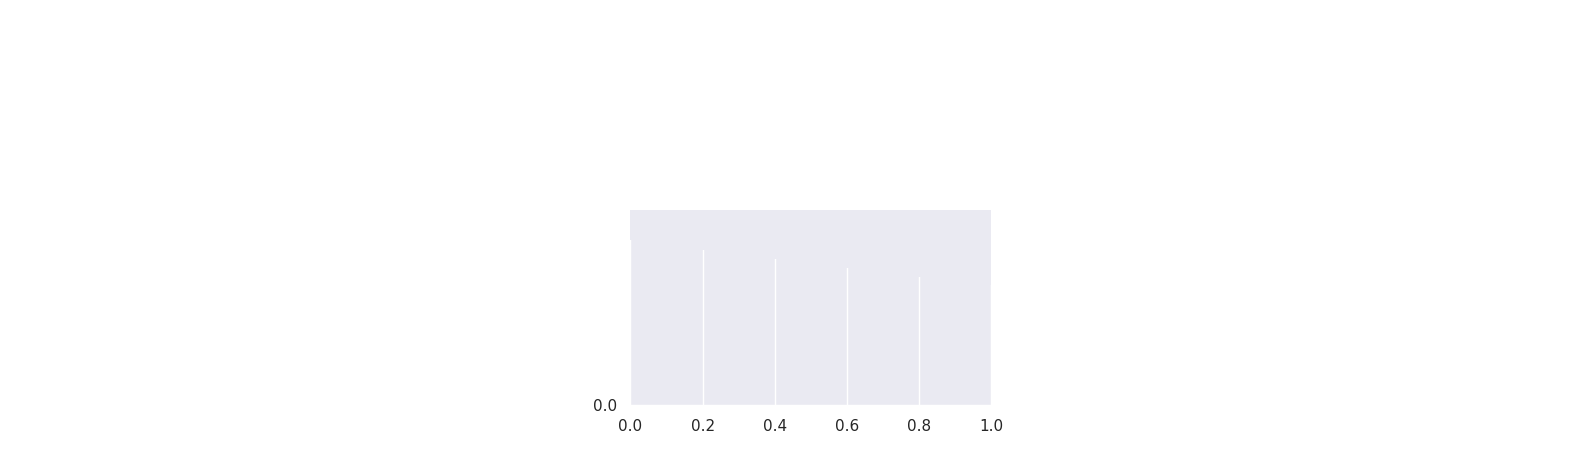

In [8]:
# Explore factors and the summing-out operation.
utils.cell3_1_factor_operations_widget()

**Guided usage**
- Pick a factor with a scope of 3 variables, then sum out one of them
  - Observe the row count drop from 8 to 4: summing out one variable
    halves the table, one dimension at a time
- Switch `Factor` to a CPT with only 1 variable in scope
  - Observe `Sum out` leaves a `(scalar)` factor: summing out every
    remaining variable collapses the table to a single number

## Cell 3.2: Variable elimination step by step

**Goal**:
- Walk through variable elimination on the alarm query, one elimination
  at a time, and compare its operation count against enumeration

**Implementation**: `cell3_2_variable_elimination_widget()`
- Advances `step` through `_variable_elimination_steps()`, which
  eliminates hidden variables in the chosen `Order` and caches each new
  factor
- Tallies multiplications and additions used so far, against the fixed
  enumeration operation count

In [ ]:
hintros.print_obj_info(utils.cell3_2_variable_elimination_widget)

**Usage**
- Inputs
  - **`Order`**: which hidden variable, `Earthquake` or `Alarm`, is
    eliminated first
  - **`elimination step`**: how many variables have been eliminated so
    far, 0-2

- Panels
  - **`Active factors (step N)`**: the current factor scopes
  - **`New factor`**: the factor created at this step, or "no
    elimination yet" at step 0
  - **`Posterior and op count`**: the running posterior next to the
    enumeration-vs-VE operation comparison
  - **`Comments`**: order, step, and both operation counts

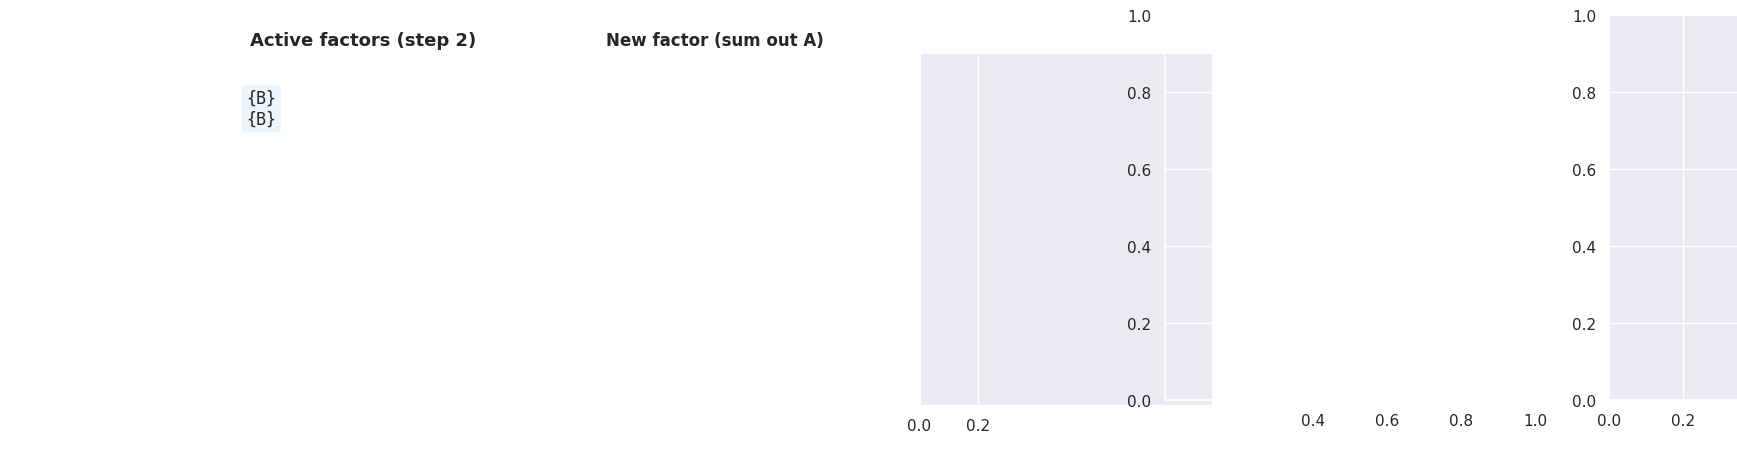

In [9]:
# Step through variable elimination one variable at a time.
utils.cell3_2_variable_elimination_widget()

**Guided usage**
- Advance `elimination step` from 0 to 2
  - Observe the active-factor list shrink by one each step, while the
    posterior bars never change: the final answer is fixed from the
    start, only the work to reach it is staged
- Compare the VE operation total in Comments against the enumeration
  count
  - Observe VE finishes with noticeably fewer operations, by reusing
    each cached factor instead of recomputing it per branch

## Cell 3.3: Pruning irrelevant variables

**Goal**:
- Show that a variable which is not an ancestor of the query or evidence
  can be deleted before any computation, for free

**Implementation**: `cell3_3_pruning_widget()`
- Builds an extended network with an extra `Neighbor` leaf, then shades
  nodes by whether they are the query, evidence, or an ancestor of
  either
- `prune irrelevant variables` compares the posterior on the full
  network against the posterior on the ancestor-only subgraph

In [ ]:
hintros.print_obj_info(utils.cell3_3_pruning_widget)

**Usage**
- Inputs
  - **`Query X`**: which node is being asked about, over the extended
    network
  - **`observe <node>`**: one checkbox plus True/False value per node
  - **`prune irrelevant variables`**: toggle between the full and
    pruned network

- Panels
  - **`Relevant (green) vs irrelevant (grey)`**: the DAG shaded by
    relevance to the current query/evidence
  - **`Full vs pruned posterior`**: bars for both networks, side by
    side
  - **`Comments`**: the irrelevant nodes and whether the two
    posteriors match

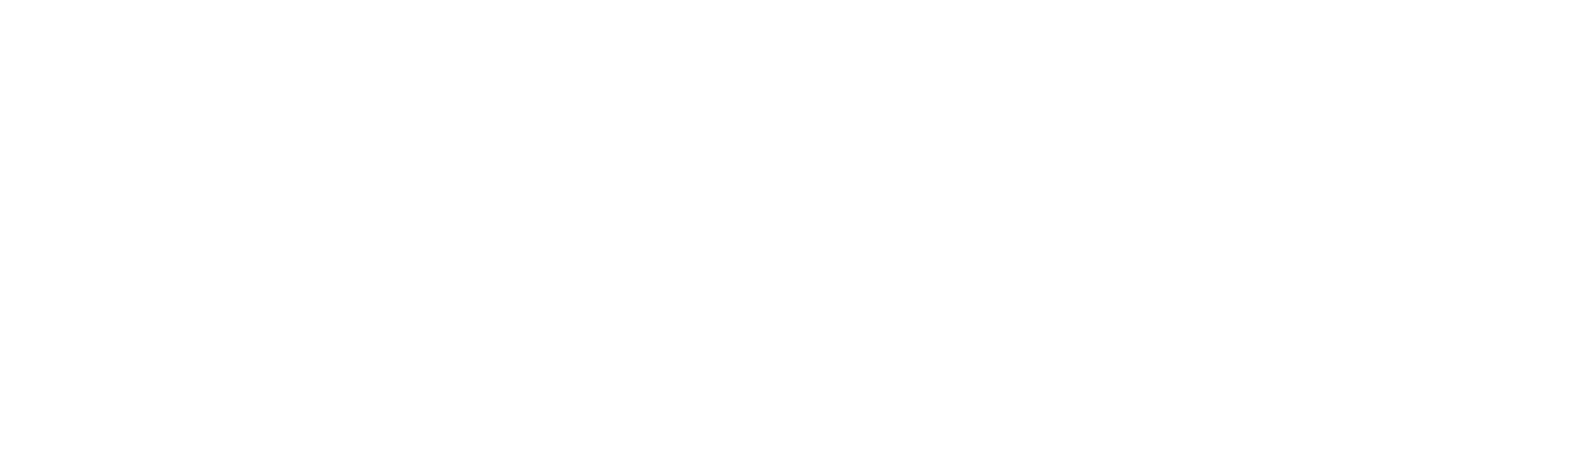

In [10]:
# Shade nodes by relevance and compare full vs pruned posteriors.
utils.cell3_3_pruning_widget()

**Guided usage**
- Leave `Neighbor` unobserved and toggle `prune irrelevant variables`
  on and off
  - Observe the posterior bars stay identical either way, while
    Comments lists `Neighbor` as irrelevant: an unobserved effect node
    with no bearing on the query contributes nothing
- Mark `Neighbor` as evidence
  - Observe it turns green (relevant) and pruning stops removing it: an
    observed node is never irrelevant, however far it sits from the
    query

# Part 4: Complexity and Limits

## Cell 4.1: Complexity: polytrees vs general graphs

**Goal**:
- Make concrete that exact inference is cheap on tree-shaped networks
  and blows up on densely connected ones

**Implementation**: `cell4_1_complexity_widget()`
- Draws a chain (`polytree`) and a fully connected graph of the same
  `n`, then plots $O(n)$ vs $O(2^n)$ operation-count curves with
  `Order quality` scaling the constant

In [ ]:
hintros.print_obj_info(utils.cell4_1_complexity_widget)

**Usage**
- Inputs
  - **`n`**: number of nodes in both example graphs, 3-10
  - **`Structure`**: which curve the marked operating point sits on,
    `polytree` or `fully connected`
  - **`Order quality`**: `good` or `bad`, scaling the cost constant

- Panels
  - **`Polytree (n=N)`**: a chain network of the chosen size
  - **`Dense network (n=N)`**: a fully connected network of the same
    size
  - **`Cost vs network size`**: the two cost curves on a log y-axis,
    with the current operating point marked
  - **`Comments`**: the operating-point cost and the role of order
    quality

In [11]:
# Compare exact-inference cost on polytrees vs dense networks.
utils.cell4_1_complexity_widget()

**Guided usage**
- Raise `n` from 3 toward 10 with `Structure` set to `fully connected`
  - Observe the marked point climb the exponential curve, while the
    same raise under `polytree` barely moves the point on the linear
    curve
- Switch `Order quality` from `good` to `bad`
  - Observe the operating-point cost jump higher at the same `n`: a
    worse elimination order inflates the constant in front of both
    curves

## Cell 4.2: When exact inference breaks down

**Goal**:
- Summarize the three regimes where exact inference is the right tool,
  or is not, and motivate the approximate methods covered next

**Implementation**: `cell4_2_breakdown_widget()`
- Looks up the chosen `Scenario` in a fixed regime table and highlights
  its row and recommendation

In [ ]:
hintros.print_obj_info(utils.cell4_2_breakdown_widget)

**Usage**
- Inputs
  - **`Scenario`**: `Small discrete polytree`, `Large dense discrete
    network`, or `Continuous variables`

- Panels
  - **`Regimes for exact inference`**: the three-regime comparison
    table, with the current scenario's row highlighted
  - **`Continuous case`**: a small DAG sketch showing
    $\sum_y \to \int dy$
  - **`Comments`**: the recommendation banner, `EXACT` or
    `APPROXIMATE`, and why

In [12]:
# Select a regime and read off the exact-vs-approximate recommendation.
utils.cell4_2_breakdown_widget()

**Guided usage**
- Step through all three `Scenario` options
  - Observe only `Small discrete polytree` recommends `EXACT`; both
    other scenarios recommend `APPROXIMATE`, for two different reasons:
    an exponential cost blowup, or a sum that is not even a finite sum
- Compare this recommendation table against Cell 4.1's cost curves
  - Observe the `Large dense discrete network` row is exactly the
    regime where Cell 4.1's exponential curve makes exact inference
    impractical